# Linear Regression
__MATH 3480__ - Dr. Michael Olson

Reading:
* Geron: Chapter 4

Additional:
* [YouTube: Serrano Academy - The Covariance Matrix](https://www.youtube.com/watch?v=WBlnwvjfMtQ)

## Regression
We have just finished talking about a number of machine learning classification models. As a reminder, classification is a form of discrete, supervised learning.

[Machine Learning Landscape](https://raw.githubusercontent.com/drolsonmi/math3480/main/Notes/Images/3480_ML_Landscape.png)

Now, we will turn our attention to regression, which would be a form of continuous, supervised learning. As we can see in our diagram, there are a number of regression models to choose from. Today, we will focus on linear regression, polynomial regression, and logistic regression.

The difference between regression and classification is that with classification, every datapoint will point to a specific class or category. With regression, however, we are dealing with continuous variables, so we are looking at a result that could be anywhere on a number scale. Most common model predictions, such as weather predictions, use regression models.

-----
## Variance, Covariance, Correlation
We've already learned about linear regression. It is a model that we learned about in basics statistics classes. The idea is to find a line that fits through the middle of your data and then use that line to estimate a result based on your inputs.

<Axes: xlabel='petal_length', ylabel='petal_width'>

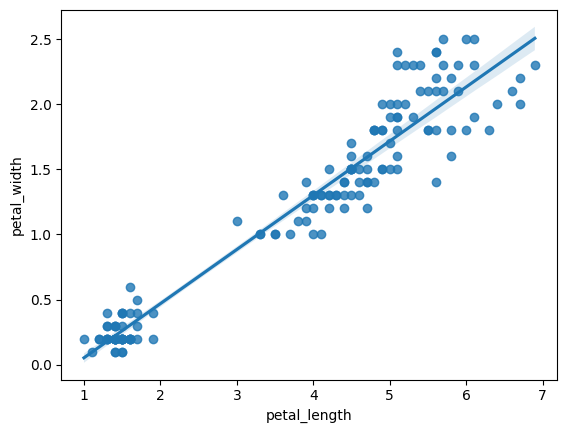

In [1]:
import seaborn as sns
iris = sns.load_dataset('iris')
sns.regplot(data=iris, x='petal_length', y='petal_width')

Define two datasets,
$$X=\{x_0,x_1,x_2,\dots\}\qquad Y=\{y_0,y_1,y_2,\dots\}$$

The __mean__ of the two datasets are found as,
$$(\mu_x,\mu_y) = \left(\frac{1}{n}\sum_{i=1}^n x_i, \frac{1}{n}\sum_{i=1}^n y_i\right)$$

The __variance__ is the average squared distance from the mean.
$$var(X) = \frac{1}{n-1}\sum_{i=1}^n (x_i-\mu_x)^2 \qquad\qquad var(Y) = \frac{1}{n-1}\sum_{i=1}^n (y_i-\mu_y)^2$$

But the variance doesn't tell the whole story. Look at the variance of these two datasets:
| $X_1$ | $Y_1$ |     | $X_2$ | $Y_2$ |
| :---: | :---: | --- | :---: | :---: |
|  -2   |   1   |     |  -2   |  -1   |
|   0   |   1   |     |   0   |  -1   |
|   0   |  -1   |     |   0   |   1   |
|   2   |  -1   |     |   2   |   1   |

$$var(X_1) = 2 \qquad var(X_2) = 2$$
$$var(Y_1) = 1 \qquad var(Y_2) = 1$$

They have the same variance, but the behavior is very different. So, we need to look at the how the variances of the two variables relate with each other. 
* Note the extreme points. 
  * If the product of the extreme points is negative, that means we are in quandrants II and IV, so we have a negative relationship.
  * If the product of the extreme points is positive, that means we are in quandrants I and III, so we have a positive relationship.

The __covariance__ is then the average product of the different dimensions.
$$cov(X,Y) = \frac{1}{n-1}\sum_{i=1}^n (x_i-\mu_x)(y_i-\mu_y)$$

Finally, the __correlation__, which tells us the strength of the relationship between the two variables, is,
$$corr[A,B] = \frac{cov[X,Y]}{\sigma_x\sigma_y} = \frac{cov[X,Y]}{\sqrt{var[X]var[Y]}}= \frac{1}{n-1}\sum\left(\frac{x-\mu_x}{\sigma_x}\frac{y-\mu_y}{\sigma_y}\right)$$

#### Example
* Find the variance of A and of B, then find the covariance between them

    |   X   |   5   |   4   |   7   |   8   |   3   |   5   |   6   |
    | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
    |   Y   |  42   |  37   |  44   |  46   |  36   |  37   |  40   |

$$\bar{X}=\frac{5+4+7+8+3+5+6}{7} = 5.4286 \qquad \bar{Y} = \frac{42+37+44+46+36+37+40}{7} = 40.2857$$

$$\begin{align*}var(X) &= \frac{1}{7-1}\left[(5-5.4286)^2 + (4-5.4286)^2 + (7-5.4286)^2 + (8-5.4286)^2 + (3-5.4286)^2 \right.\\
  &\qquad\qquad\left.+ (5-5.4286)^2 + (6-5.4286)^2\right] \\
  &= \frac{1}{6}\left[(-0.4286)^2+(-1.4286)^2+(1.5714)^2+(2.5714)^2+(-2.4286)^2+(-0.4286)^2+(0.5714)^2\right] \\
  &= \frac{1}{6}\left[0.1837+2.0408+2.4694+6.6122+5.8980+0.1837+0.3265\right]\\
  &= \frac{1}{6}(17.7143)\\
  &= 2.9524
  \end{align*}$$

$$\begin{align*}var(Y) &= \frac{1}{7-1}\left[(42-40.2857)^2 + (37-40.2857)^2 + (44-40.2857)^2 + (46-40.2857)^2 + (36-40.2857)^2 \right.\\
  &\qquad\qquad\left. + (37-40.2857)^2 + (40-40.2857)^2\right] \\
  &= \frac{1}{6}\left[(1.7143)^2 + (-3.2857)^2 + (3.7143)^2 + (5.7143)^2 + (-4.2857)^2 + (-3.2857)^2 + (-0.2857)^2\right] \\
  &= \frac{1}{6}\left[(2.9388) + (10.7959) + (13.7959) + (32.6531) + (18.3673) + (10.7959) + (0.0816)\right]\\
  &= \frac{1}{6}(89.4286) \\
  &= 14.9048
  \end{align*}$$

$$\begin{align*}cov(X,Y) &= \frac{1}{7-1}\left[(5-5.4286)(42-40.2857) + (4-5.4286)(37-40.2857) + (7-5.4286)(44-40.2857) \right.\\
  &\qquad\qquad\left. + (8-5.4286)(46-40.2857) + (3-5.4286)(36-40.2857) \right. \\
  &\qquad\qquad\left. + (5-5.4286)(37-40.2857) + (6-5.4286)(40-40.2857) \right] \\
  &= \frac{1}{6}\left[(-0.4286)(1.7143) + (-1.4286)(-3.2857) + (1.5714)(3.7143) + (2.5714)(5.7143) \right. \\
  &\qquad\left. + (-2.4286)(-4.2857) + (-0.4286)(-3.2857) + (0.5714)(-0.2857)\right] \\
  &= \frac{1}{6}\left[-0.7347+4.6939+5.8367+14.6939+10.4082+1.4082-0.1633\right] \\
  &= \frac{1}{6}(36.1429) \\
  &= 6.0238
  \end{align*}$$

$$corr(X,Y) = \frac{cov(X,Y)}{\sqrt{var(X)var(Y)}} = \frac{6.0238}{\sqrt{2.9524*14.9048}} = 0.9081$$

In [1]:
import numpy as np
X = np.array([5,4,7,8,3,5,6])
Y = np.array([42,37,44,46,36,37,40])

print(X.mean(), Y.mean())

print('The default for var(x) is 1/n (a population). Default argument for this is ddof=0')
print(np.var(X))
print(np.var(Y))

print('\nTo make it a sample [1/(n-1)], change ddof=1')
print(np.var(X, ddof=1))
print(np.var(Y, ddof=1))

print('\nThe default for the covariance is ddof=1')
print(np.cov(X,Y))

print('\nTo obtain just the covariance of X and Y, we can use np.cov(X,Y)[0,1] or np.cov(X,Y)[1,0]')
print(np.cov(X,Y)[0,1])

5.428571428571429 40.285714285714285
The default for var(x) is 1/n (a population). Default argument for this is ddof=0
2.5306122448979593
12.77551020408163

To make it a sample [1/(n-1)], change ddof=1
2.9523809523809526
14.904761904761903

The default for the covariance is ddof=1
[[ 2.95238095  6.02380952]
 [ 6.02380952 14.9047619 ]]

To obtain just the covariance of X and Y, we can use np.cov(X,Y)[0,1] or np.cov(X,Y)[1,0]
6.023809523809523


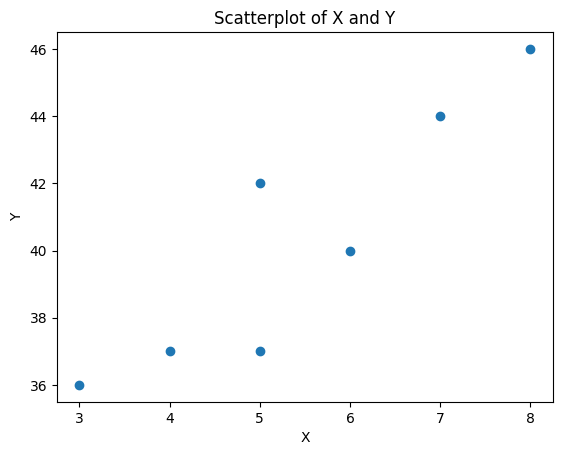

In [2]:
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X and Y')
plt.show()

## Linear Regression
From our statistical learning, we saw that the data follows the function,

$$y = f(x) + \epsilon$$

As a data scientist, we want to approximate $f(x)$ as,

$$\hat{y} = \hat{f}(x) \approx f(x)$$

In this case, $f(x)$ appears to follow a line $f(x) = mx + b$. So, we need a similar line:

$$\hat{f}(x) = \beta_0 + \beta_1 x$$

$\beta_0$ is known as the __bias__ and $\beta_1$ is known as the weight.
* Note that in future models, as can incorporate more variables into what we call __multi-linear regression__:
    $$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \dots$$
* Each $\beta_i$ will determine how much $x_i$ weighs into the model. Hence why we call it a weight.

Finding $\beta_0$ and $\beta_1$ in a 2-variable case is quite simple. We start with the weight:

$$\beta_1 = \frac{cov(X,Y)}{\sigma_x\sigma_x} = \frac{cov(X,Y)}{var(X)}$$

Once we have the weight, we take a value we know must be in the model and plug it into the equation. The simplest point would be the midpoint: $(\bar{x},\bar{y})$.

$$\bar{y} = \beta_0 + \beta_1 \bar{x} \qquad \qquad \beta_0 = \bar{y} - b_1\bar{x}$$

Back to our example,

$$\beta_1 = \frac{cov(X,Y)}{var(X)} = \frac{6.0238}{2.9524} = 2.3804$$

$$\beta_0 = \bar{Y} - \beta_1\bar{X} = 40.2857 - 2.3804(5.4286) = 27.3637$$

The full equation of our model is then,

$$y = 27.3637 + 2.3804x$$

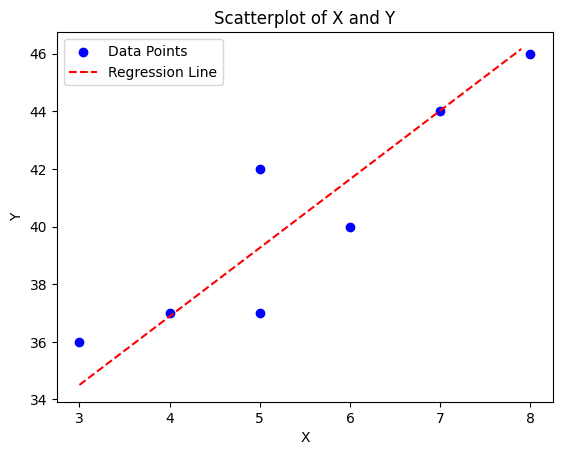

In [3]:
plt.scatter(X,Y, color='blue', label='Data Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X and Y')

x_test = np.arange(3,8,0.1)
y_test = 27.3637 + 2.3804*x_test
plt.plot(x_test, y_test, color='red', linestyle='--', label='Regression Line')
plt.legend()
plt.show()

## Python hint: returning multiple values from a function
You can return multiple values from a function within python. This is useful when you need to return both a weight and a bias in your model.

In [3]:
def lin_reg(x,y):
    a = x+y   # put your function here
    b = x*y   # put your function here
    return a, b

b0, b1 = lin_reg(4,7)
print(f"b0 = {b0} and b1 = {b1}")

b0 = 11 and b1 = 28


## Linear Regression with Iris Dataset
Find the linear regression line for the iris dataset using the Petal Length and the Petal Width. Then test it with the following numbers and evaluate using a MSE.
| Petal Length | Petal Width |
| :----------: | :---------: |
|  3.0         |   0.9       |
|  2.5         |   0.8       |
|  5.0         |   1.2       |
|  4.3         |   1.5       |
|  1.2         |   0.2       |

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


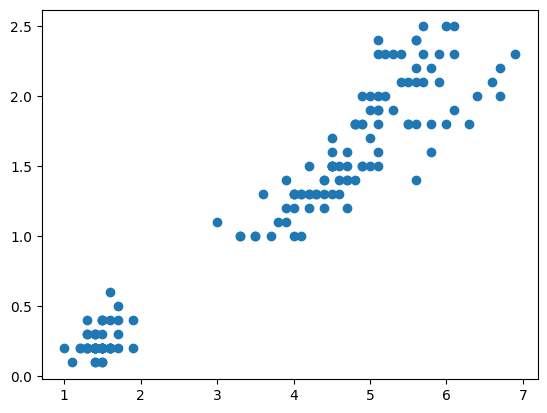

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')
display(iris.head())

plt.scatter(iris['petal_length'], iris['petal_width'])

y = -0.3735614867864949 + 0.4185457211601459x


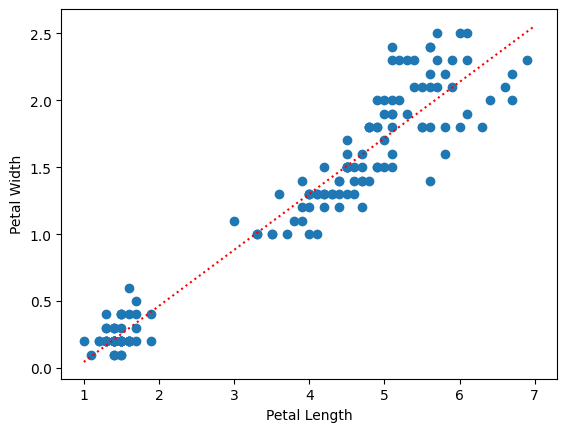

In [40]:
# Train model

X = iris['petal_length'] - iris['petal_length'].mean()
Y = iris['petal_width'] - iris['petal_width'].mean()


b1 = np.cov(X,Y)[1,0]/np.var(X)
b0 = (iris['petal_width'].mean()) - b1*(iris['petal_length'].mean())

print(f"y = {b0} + {b1}x")

plt.scatter(iris['petal_length'], iris['petal_width'])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

# Show linear regression
x_line = np.linspace(1,7,100)
y_line = b0 + b1*x_line

plt.plot(x_line, y_line, c='red', linestyle=':')

plt.show()

### Predictions

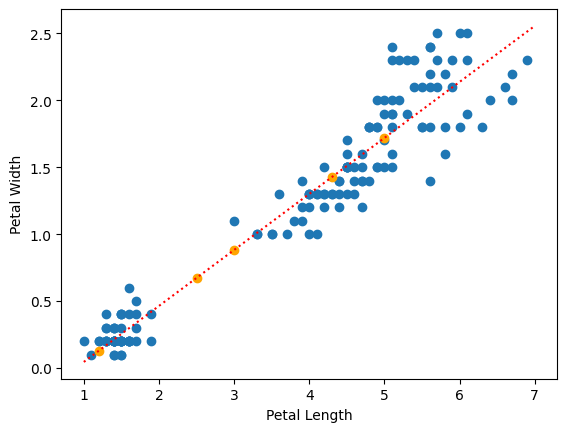

In [42]:
# Make predictions using the regression line
X_test = np.array([3, 2.5, 5, 4.3, 1.2])
y_true = np.array([0.9, 0.8, 1.2, 1.5, 0.2])
y_pred = b0 + b1*X_test

plt.scatter(iris['petal_length'], iris['petal_width'])
plt.plot(x_line, y_line, c='red', linestyle=':')
plt.scatter(X_test, y_pred, c='orange')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.show()

### Evaluating the Model

In [45]:
mse = (1/len(y_true))*((y_true - y_pred)**2).sum()
print(f"MSE = {mse:0.4f}. That is {100*mse/y_true.mean():0.4f}% of the true mean")

MSE = 0.0593. That is 6.4471% of the true mean
